# Lab 3 — Portfolio Replica Strategy
## Part 1: Data Ingestion, EDA, Autocorrelation, Monster Index

**Sections covered:**
1. Data Ingestion
2. Exploratory Data Analysis
   - 2.2 Annualized Statistics (incl. Calmar Ratio)
   - 2.2b Futures Descriptive Statistics
   - 2.8 Formal Normality Test — Jarque-Bera
3. Autocorrelation Analysis
   - 3.0 Stationarity Test — ADF
   - 3.4 Formal Volatility Clustering — ARCH LM
4. Monster Index Construction
5. Target Index Statistics
   - 5.5 Principal Component Analysis on Futures
6. Deliverable: `target_returns` + `futures_returns`

---
## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.5)

---
## 1. Data Ingestion

In [2]:
file_path = 'Dataset3_PortfolioReplicaStrategy.xlsx'

# ── Load price levels ─────────────────────────────────────────────────────────
# header=0  → row 1 of the Excel file is the column header
# index_col=0 → first column (dates) becomes the DatetimeIndex
prices = pd.read_excel(file_path, header=0, index_col=0, parse_dates=True)

# ── Human-readable labels ─────────────────────────────────────────────────────
LABEL = {
    'MXWO':     'MSCI World',
    'MXWD':     'MSCI ACWI',
    'LEGATRUU': 'Global Aggregate Bond',
    'HFRXGL':   'HFRX Hedge Fund Global',
    'RX1':  'Bund Future (10Y GER)',
    'TY1':  '10Y US Treasury Future',
    'GC1':  'Gold Future',
    'CO1':  'Brent Crude Future',
    'ES1':  'S&P 500 Future',
    'VG1':  'EuroStoxx 50 Future',
    'NQ1':  'Nasdaq 100 Future',
    'LLL1': 'MSCI EM Future',
    'TP1':  'TOPIX Future',
    'DU1':  'Schatz 2Y GER Future',
    'TU2':  '2Y US Treasury Future',
}

# ── Column groups ─────────────────────────────────────────────────────────────
TARGET_COLS  = ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL']
FUTURES_COLS = ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1',
                'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']
ANN = 52  # weekly → annual scaling

# ── Compute weekly returns ────────────────────────────────────────────────────
# pct_change() produces NaN only on the very first row → dropna() removes it
returns = prices.pct_change().dropna()

# ── Sanity checks ─────────────────────────────────────────────────────────────
print(f"Price levels  : {prices.shape[0]} rows × {prices.shape[1]} cols")
print(f"Weekly returns: {returns.shape[0]} rows × {returns.shape[1]} cols")
print(f"Date range    : {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Columns       : {returns.columns.tolist()}")
print()
display(prices.head())
display(returns.describe().round(6))

Price levels  : 705 rows × 15 cols
Weekly returns: 704 rows × 15 cols
Date range    : 2007-10-30 → 2021-04-20
Columns       : ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL', 'RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1', 'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']



,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Ticker,,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.0,2212.00,1287.0,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.0,2217.75,1323.9,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.0,2233.50,1320.0,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.0,2066.75,1271.0,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.0,2035.50,1225.2,1472.5,103.800,104.945312


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
count,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000
mean,0.001135,0.001059,0.000647,0.000096,0.000615,0.000289,0.001509,0.001252,0.001697,0.000286,0.002973,0.000102,0.000788,0.000116,0.000089
std,0.024301,0.024662,0.007402,0.006635,0.008511,0.007812,0.024575,0.056417,0.023590,0.030090,0.026945,0.025101,0.031296,0.001564,0.001756
min,-0.135977,-0.136837,-0.046845,-0.057084,-0.031871,-0.042684,-0.125709,-0.346959,-0.139649,-0.135896,-0.167030,-0.242176,-0.181044,-0.008456,-0.008419
25%,-0.008941,-0.009935,-0.003317,-0.002386,-0.003853,-0.003995,-0.012496,-0.025593,-0.007231,-0.014503,-0.010335,0.000000,-0.014586,-0.000449,-0.000720
50%,0.003909,0.003538,0.000682,0.000952,0.001134,0.000708,0.002198,0.002953,0.003815,0.002137,0.006392,0.000000,0.002837,0.000090,0.000071
75%,0.013412,0.014067,0.004730,0.003786,0.005539,0.004513,0.015542,0.028213,0.014149,0.016977,0.018244,0.000000,0.018099,0.000699,0.000855
max,0.129412,0.139035,0.035393,0.022268,0.027871,0.033656,0.140008,0.513685,0.087640,0.183577,0.084935,0.206501,0.153119,0.006883,0.008272


### 1.1 Data Quality Check

In [3]:
nan_counts = prices.isnull().sum()

print("Missing values (NaN) per column in prices:")
print("=" * 45)
for col, count in nan_counts.items():
    label = LABEL.get(col, col)
    flag  = " ← NaN present" if count > 0 else ""
    print(f"  {col:10s} ({label:30s}): {count:3d}{flag}")

print(f"\nTotal NaN across all columns: {nan_counts.sum()}")
print()
print("Le righe con valori NaN, dovute principalmente al disallineamento dei calendari")
print("di borsa (festività locali), verranno gestite e rimosse nel calcolo dei rendimenti")
print("tramite dropna()")

Missing values (NaN) per column in prices:
  MXWO       (MSCI World                    ):   0
  MXWD       (MSCI ACWI                     ):   0
  LEGATRUU   (Global Aggregate Bond         ):   0
  HFRXGL     (HFRX Hedge Fund Global        ):   0
  RX1        (Bund Future (10Y GER)         ):   0
  TY1        (10Y US Treasury Future        ):   0
  GC1        (Gold Future                   ):   0
  CO1        (Brent Crude Future            ):   0
  ES1        (S&P 500 Future                ):   0
  VG1        (EuroStoxx 50 Future           ):   0
  NQ1        (Nasdaq 100 Future             ):   0
  LLL1       (MSCI EM Future                ):   0
  TP1        (TOPIX Future                  ):   0
  DU1        (Schatz 2Y GER Future          ):   0
  TU2        (2Y US Treasury Future         ):   0

Total NaN across all columns: 0

Le righe con valori NaN, dovute principalmente al disallineamento dei calendari
di borsa (festività locali), verranno gestite e rimosse nel calcolo dei rendim

---
## 2. Exploratory Data Analysis

### 2.1 Normalized Price Series (Base = 100)

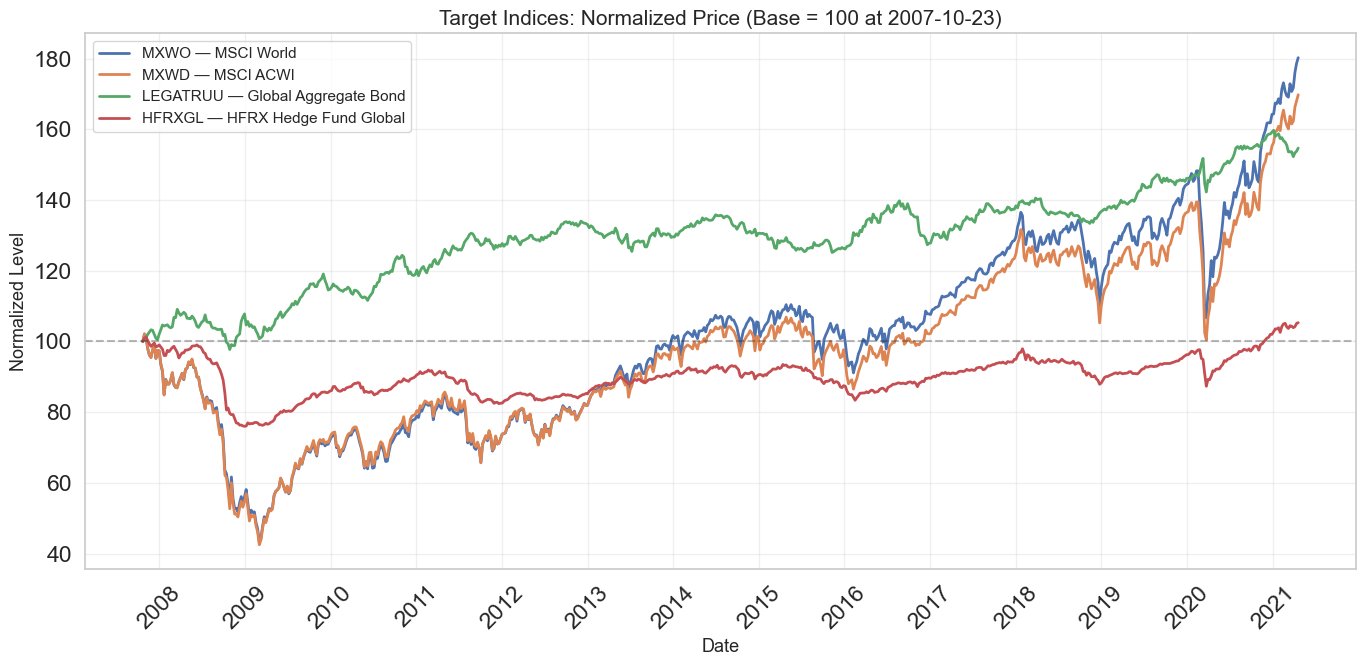

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))

for col in TARGET_COLS:
    norm = prices[col] / prices[col].iloc[0] * 100
    ax.plot(norm, linewidth=2, label=f"{col} — {LABEL[col]}")

ax.axhline(100, color='k', linestyle='--', alpha=0.3)
ax.set_title('Target Indices: Normalized Price (Base = 100 at 2007-10-23)', fontsize=15)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Normalized Level', fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Annualized Statistics

In [5]:
def fmt_pct(x):
    return f"{x * 100:.2f}%"

stats_tbl = pd.DataFrame({
    'Ann. Return':     returns[TARGET_COLS].mean() * ANN,
    'Ann. Volatility': returns[TARGET_COLS].std() * np.sqrt(ANN),
    'Sharpe Ratio':   (returns[TARGET_COLS].mean() * ANN) /
                      (returns[TARGET_COLS].std() * np.sqrt(ANN)),
    'Max Drawdown':    returns[TARGET_COLS].apply(
                          lambda x: ((1 + x).cumprod() /
                                     (1 + x).cumprod().cummax() - 1).min()),
    'Calmar Ratio':    returns[TARGET_COLS].apply(
                          lambda x: (x.mean() * ANN) /
                          abs(((1 + x).cumprod() / (1 + x).cumprod().cummax() - 1).min())),
    'Skewness':        returns[TARGET_COLS].skew(),
    'Kurtosis':        returns[TARGET_COLS].kurtosis(),
})

for col in ['Ann. Return', 'Ann. Volatility', 'Max Drawdown']:
    stats_tbl[col] = stats_tbl[col].apply(fmt_pct)
stats_tbl['Sharpe Ratio'] = stats_tbl['Sharpe Ratio'].round(3)
stats_tbl['Calmar Ratio'] = stats_tbl['Calmar Ratio'].round(3)
stats_tbl['Skewness']     = stats_tbl['Skewness'].round(3)
stats_tbl['Kurtosis']     = stats_tbl['Kurtosis'].round(3)

print("Annualized statistics for target indices (weekly data, 2007-2021):")
display(stats_tbl)

Annualized statistics for target indices (weekly data, 2007-2021):


,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis
MXWO,5.90%,17.52%,0.337,-57.61%,0.102,-0.682,4.357
MXWD,5.51%,17.78%,0.310,-58.39%,0.094,-0.641,4.663
LEGATRUU,3.37%,5.34%,0.630,-10.41%,0.323,-0.330,4.118
HFRXGL,0.50%,4.78%,0.104,-24.91%,0.020,-2.301,13.702


### 2.3 Futures Descriptive Statistics

Same metrics computed for the 11 replication instruments. Understanding each future's risk/return profile identifies which contracts are viable as long or short legs in the replica portfolio.

In [6]:
futures_stats = pd.DataFrame({
    'Ann. Return':     returns[FUTURES_COLS].mean() * ANN,
    'Ann. Volatility': returns[FUTURES_COLS].std() * np.sqrt(ANN),
    'Sharpe Ratio':   (returns[FUTURES_COLS].mean() * ANN) /
                      (returns[FUTURES_COLS].std() * np.sqrt(ANN)),
    'Calmar Ratio':    returns[FUTURES_COLS].apply(
                          lambda x: (x.mean() * ANN) /
                          abs(((1 + x).cumprod() / (1 + x).cumprod().cummax() - 1).min())),
    'Max Drawdown':    returns[FUTURES_COLS].apply(
                          lambda x: ((1 + x).cumprod() /
                                     (1 + x).cumprod().cummax() - 1).min()),
    'Skewness':        returns[FUTURES_COLS].skew(),
    'Kurtosis':        returns[FUTURES_COLS].kurtosis(),
})

futures_stats.index = [f"{col} — {LABEL[col]}" for col in FUTURES_COLS]
for col in ['Ann. Return', 'Ann. Volatility', 'Max Drawdown']:
    futures_stats[col] = futures_stats[col].apply(fmt_pct)
for col in ['Sharpe Ratio', 'Calmar Ratio', 'Skewness', 'Kurtosis']:
    futures_stats[col] = futures_stats[col].round(3)

print("Annualized statistics for futures contracts (weekly data, 2007-2021):")
display(futures_stats)

Annualized statistics for futures contracts (weekly data, 2007-2021):


,Ann. Return,Ann. Volatility,Sharpe Ratio,Calmar Ratio,Max Drawdown,Skewness,Kurtosis
RX1 — Bund Future (10Y GER),3.20%,6.14%,0.521,0.308,-10.39%,-0.519,1.608
TY1 — 10Y US Treasury Future,1.50%,5.63%,0.267,0.116,-12.90%,-0.406,3.090
GC1 — Gold Future,7.85%,17.72%,0.443,0.182,-43.18%,0.052,3.466
CO1 — Brent Crude Future,6.51%,40.68%,0.160,0.076,-86.26%,1.068,16.381
ES1 — S&P 500 Future,8.83%,17.01%,0.519,0.160,-55.11%,-1.038,5.168
VG1 — EuroStoxx 50 Future,1.49%,21.70%,0.068,0.026,-58.15%,-0.089,3.602
NQ1 — Nasdaq 100 Future,15.46%,19.43%,0.796,0.297,-52.00%,-0.943,3.923
LLL1 — MSCI EM Future,0.53%,18.10%,0.029,0.008,-64.87%,-0.573,25.943
TP1 — TOPIX Future,4.10%,22.57%,0.182,0.073,-56.29%,-0.683,5.145
DU1 — Schatz 2Y GER Future,0.60%,1.13%,0.536,0.218,-2.77%,-0.239,5.196


### 2.4 Correlation Heatmap

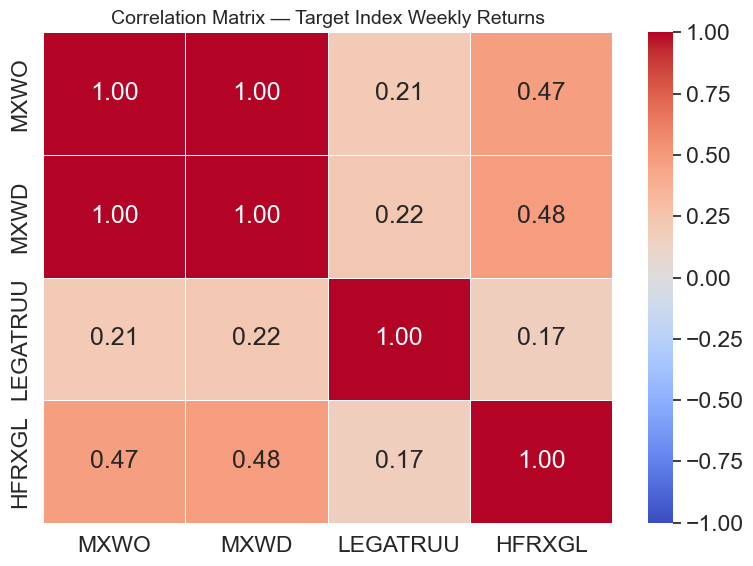

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = returns[TARGET_COLS].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Target Index Weekly Returns', fontsize=14)
plt.tight_layout()
plt.show()

### 2.5 Return Distributions

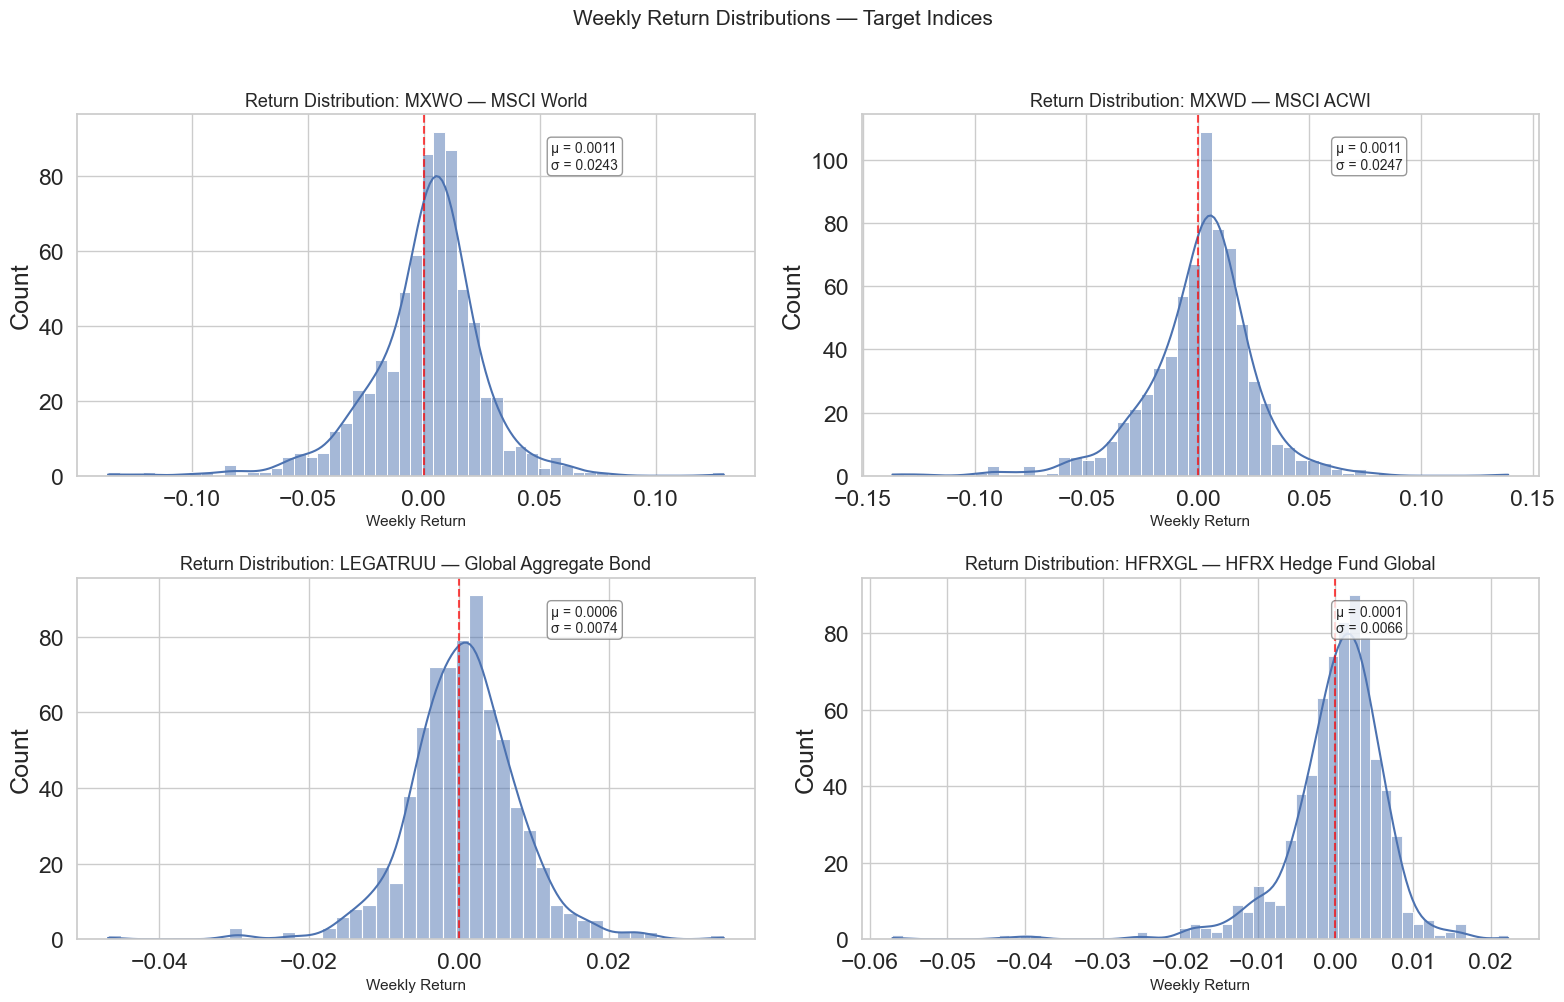

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, col in zip(axes.flatten(), TARGET_COLS):
    sns.histplot(returns[col], kde=True, ax=ax)
    ax.set_title(f'Return Distribution: {col} — {LABEL[col]}', fontsize=13)
    ax.set_xlabel('Weekly Return', fontsize=11)
    ax.axvline(0, color='red', linestyle='--', alpha=0.7)
    ax.annotate(
        f"μ = {returns[col].mean():.4f}\nσ = {returns[col].std():.4f}",
        xy=(0.70, 0.85), xycoords='axes fraction',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8),
        fontsize=10
    )

plt.suptitle('Weekly Return Distributions — Target Indices', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 2.6 Cumulative Returns

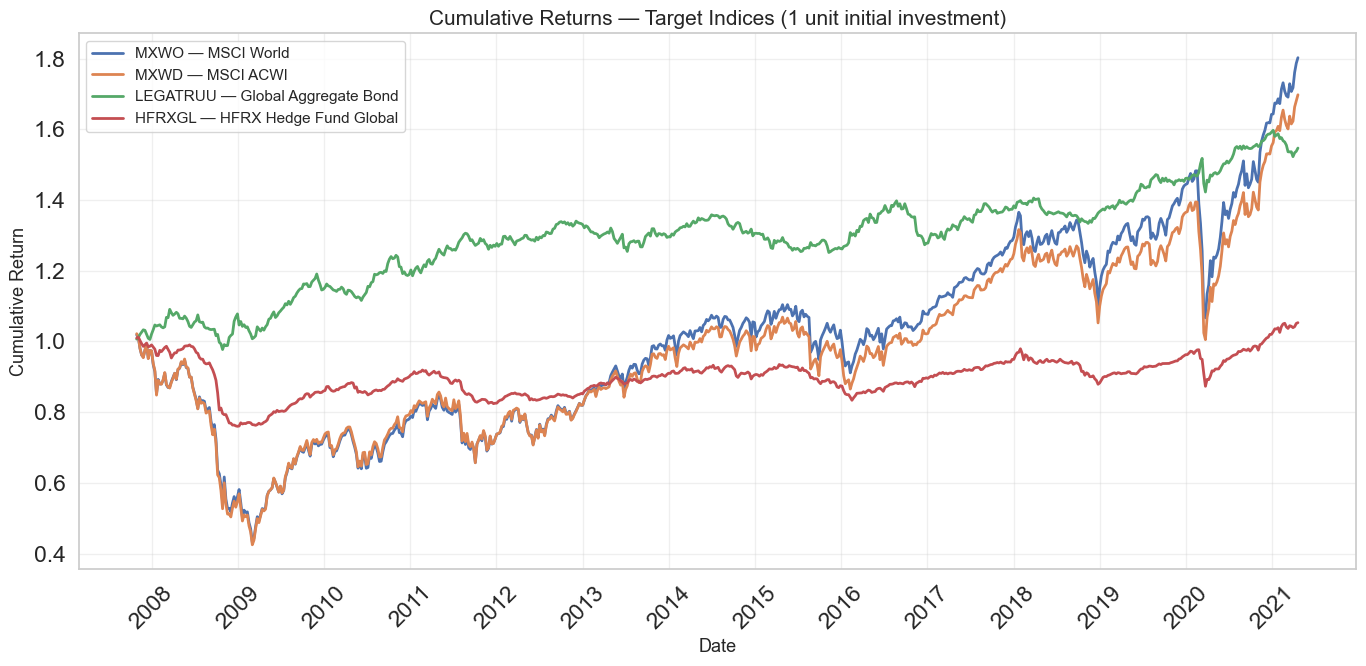

In [9]:
cum_ret = (1 + returns[TARGET_COLS]).cumprod()

fig, ax = plt.subplots(figsize=(14, 7))
for col in TARGET_COLS:
    ax.plot(cum_ret[col], linewidth=2, label=f"{col} — {LABEL[col]}")

ax.set_title('Cumulative Returns — Target Indices (1 unit initial investment)', fontsize=15)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Cumulative Return', fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.7 Rolling 52-Week Correlation vs HFRXGL

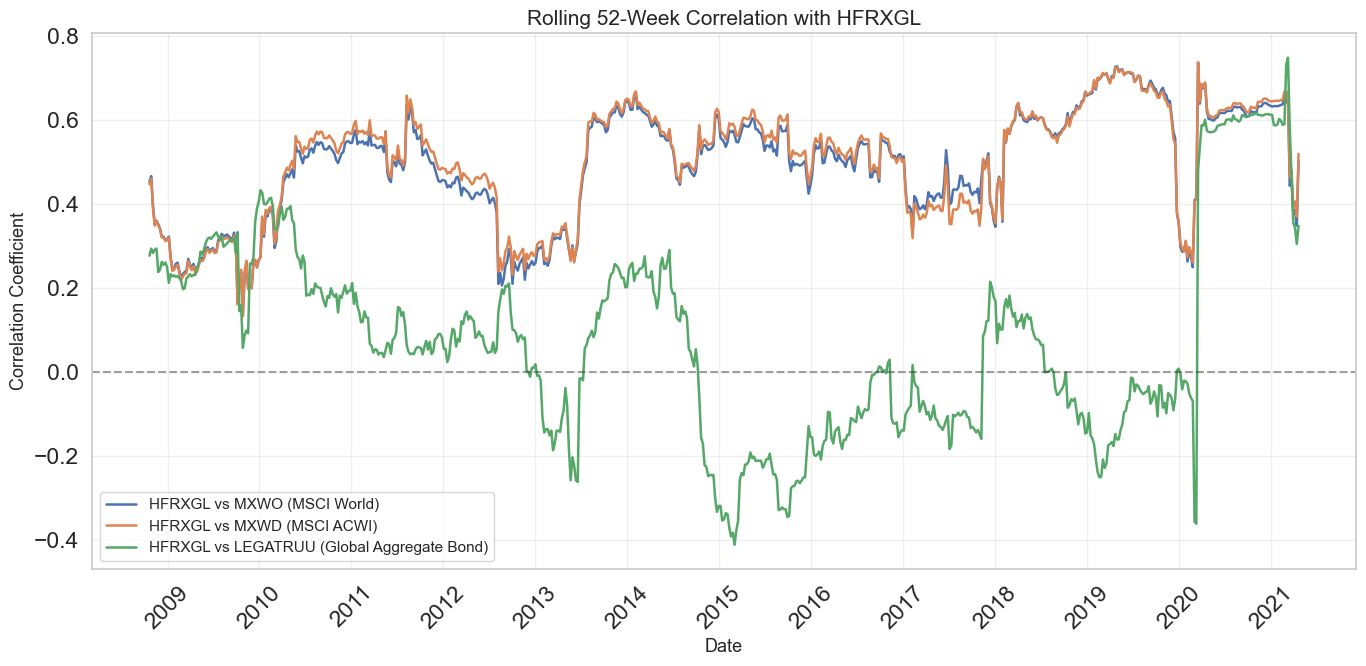

In [10]:
base_idx = 'HFRXGL'
rolling_window = 52

fig, ax = plt.subplots(figsize=(14, 7))
for col in [c for c in TARGET_COLS if c != base_idx]:
    roll_corr = returns[[base_idx, col]].rolling(rolling_window).corr().unstack()[base_idx][col]
    ax.plot(roll_corr, linewidth=1.8, label=f"{base_idx} vs {col} ({LABEL[col]})")

ax.axhline(0, color='k', linestyle='--', alpha=0.4)
ax.set_title(f'Rolling {rolling_window}-Week Correlation with {base_idx}', fontsize=15)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Correlation Coefficient', fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.8 QQ Plots — Weekly Returns vs Normal Distribution

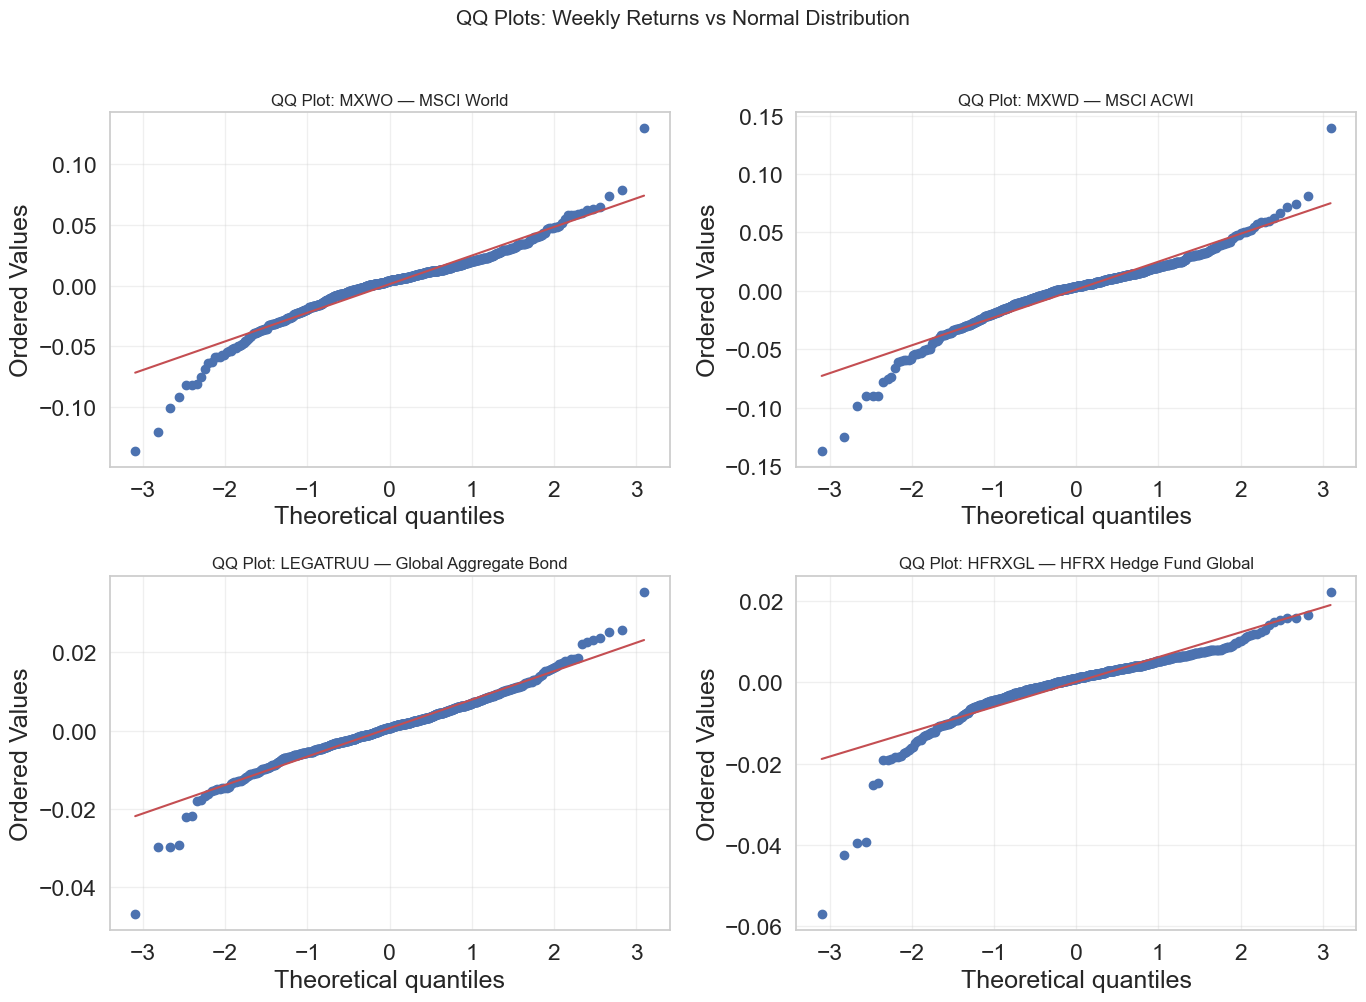

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), TARGET_COLS):
    stats.probplot(returns[col].dropna(), dist='norm', plot=ax)
    ax.set_title(f'QQ Plot: {col} — {LABEL[col]}', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.suptitle('QQ Plots: Weekly Returns vs Normal Distribution', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 2.9 Formal Normality Test — Jarque-Bera

**H₀**: Returns follow a normal distribution. The test combines skewness and excess kurtosis into a single statistic, providing a formal complement to the QQ plots above.

In [12]:
print("Jarque-Bera normality test (H₀: returns follow a normal distribution)")
print("=" * 68)

for col in TARGET_COLS:
    jb_stat, jb_pval = stats.jarque_bera(returns[col].dropna())
    stars = '***' if jb_pval < 0.001 else \
            '** ' if jb_pval < 0.01  else \
            '*  ' if jb_pval < 0.05  else '   '
    conclusion = "Non-normal" if jb_pval < 0.05 else "Normal"
    print(f"{col:10s}: JB = {jb_stat:12.2f},  p = {jb_pval:.4e}  {stars}  → {conclusion}")

print("\nSignificance: *** p<0.001  ** p<0.01  * p<0.05")
print("\nAll target indices strongly reject normality — consistent with the fat tails and negative")
print("skewness visible in the QQ plots and return distributions above.")

Jarque-Bera normality test (H₀: returns follow a normal distribution)
MXWO      : JB =       601.22,  p = 2.7964e-131  ***  → Non-normal
MXWD      : JB =       674.61,  p = 3.2363e-147  ***  → Non-normal
LEGATRUU  : JB =       501.10,  p = 1.5365e-109  ***  → Non-normal
HFRXGL    : JB =      6041.57,  p = 0.0000e+00  ***  → Non-normal

Significance: *** p<0.001  ** p<0.01  * p<0.05

All target indices strongly reject normality — consistent with the fat tails and negative
skewness visible in the QQ plots and return distributions above.


---
## 3. Autocorrelation Analysis

We analyze serial dependence in weekly returns. For replication purposes, understanding autocorrelation is important:
- Equity indices (MXWO, MXWD) typically show no significant autocorrelation in weekly returns (efficient market behavior).
- **HFRXGL (hedge funds) exhibits significant autocorrelation**, especially in the 2007–2011 period, due to **stale pricing** and **illiquidity effects** typical of hedge funds — they hold less liquid assets whose prices are updated infrequently, creating artificial serial correlation. This was amplified during the 2008 financial crisis.

### 3.1 Stationarity Test — Augmented Dickey-Fuller

**H₀**: The series has a unit root (non-stationary). Rejection of H₀ confirms stationarity — a prerequisite for valid autocorrelation modeling.  
Weekly *returns* (from `pct_change()`) are expected to be stationary; price *levels* would not be.

In [13]:
print("Augmented Dickey-Fuller test (H₀: unit root / non-stationary series)")
print("=" * 68)

for col in TARGET_COLS:
    result    = adfuller(returns[col].dropna(), autolag='AIC')
    adf_stat, pval, used_lags = result[0], result[1], result[2]
    stars = '***' if pval < 0.001 else \
            '** ' if pval < 0.01  else \
            '*  ' if pval < 0.05  else '   '
    conclusion = "Stationary ✓" if pval < 0.05 else "Non-stationary ✗"
    print(f"{col:10s}: ADF = {adf_stat:8.4f},  p = {pval:.4f}  {stars}  → {conclusion}  (lags={used_lags})")

print("\nSignificance: *** p<0.001  ** p<0.01  * p<0.05")
print("\nExpected: weekly pct_change() returns are stationary by construction;")
print("price levels would show a unit root, but returns do not.")

Augmented Dickey-Fuller test (H₀: unit root / non-stationary series)
MXWO      : ADF =  -6.2776,  p = 0.0000  ***  → Stationary ✓  (lags=14)
MXWD      : ADF =  -6.2162,  p = 0.0000  ***  → Stationary ✓  (lags=14)
LEGATRUU  : ADF = -13.1936,  p = 0.0000  ***  → Stationary ✓  (lags=3)
HFRXGL    : ADF = -11.8098,  p = 0.0000  ***  → Stationary ✓  (lags=2)

Significance: *** p<0.001  ** p<0.01  * p<0.05

Expected: weekly pct_change() returns are stationary by construction;
price levels would show a unit root, but returns do not.


### 3.2 ACF and PACF

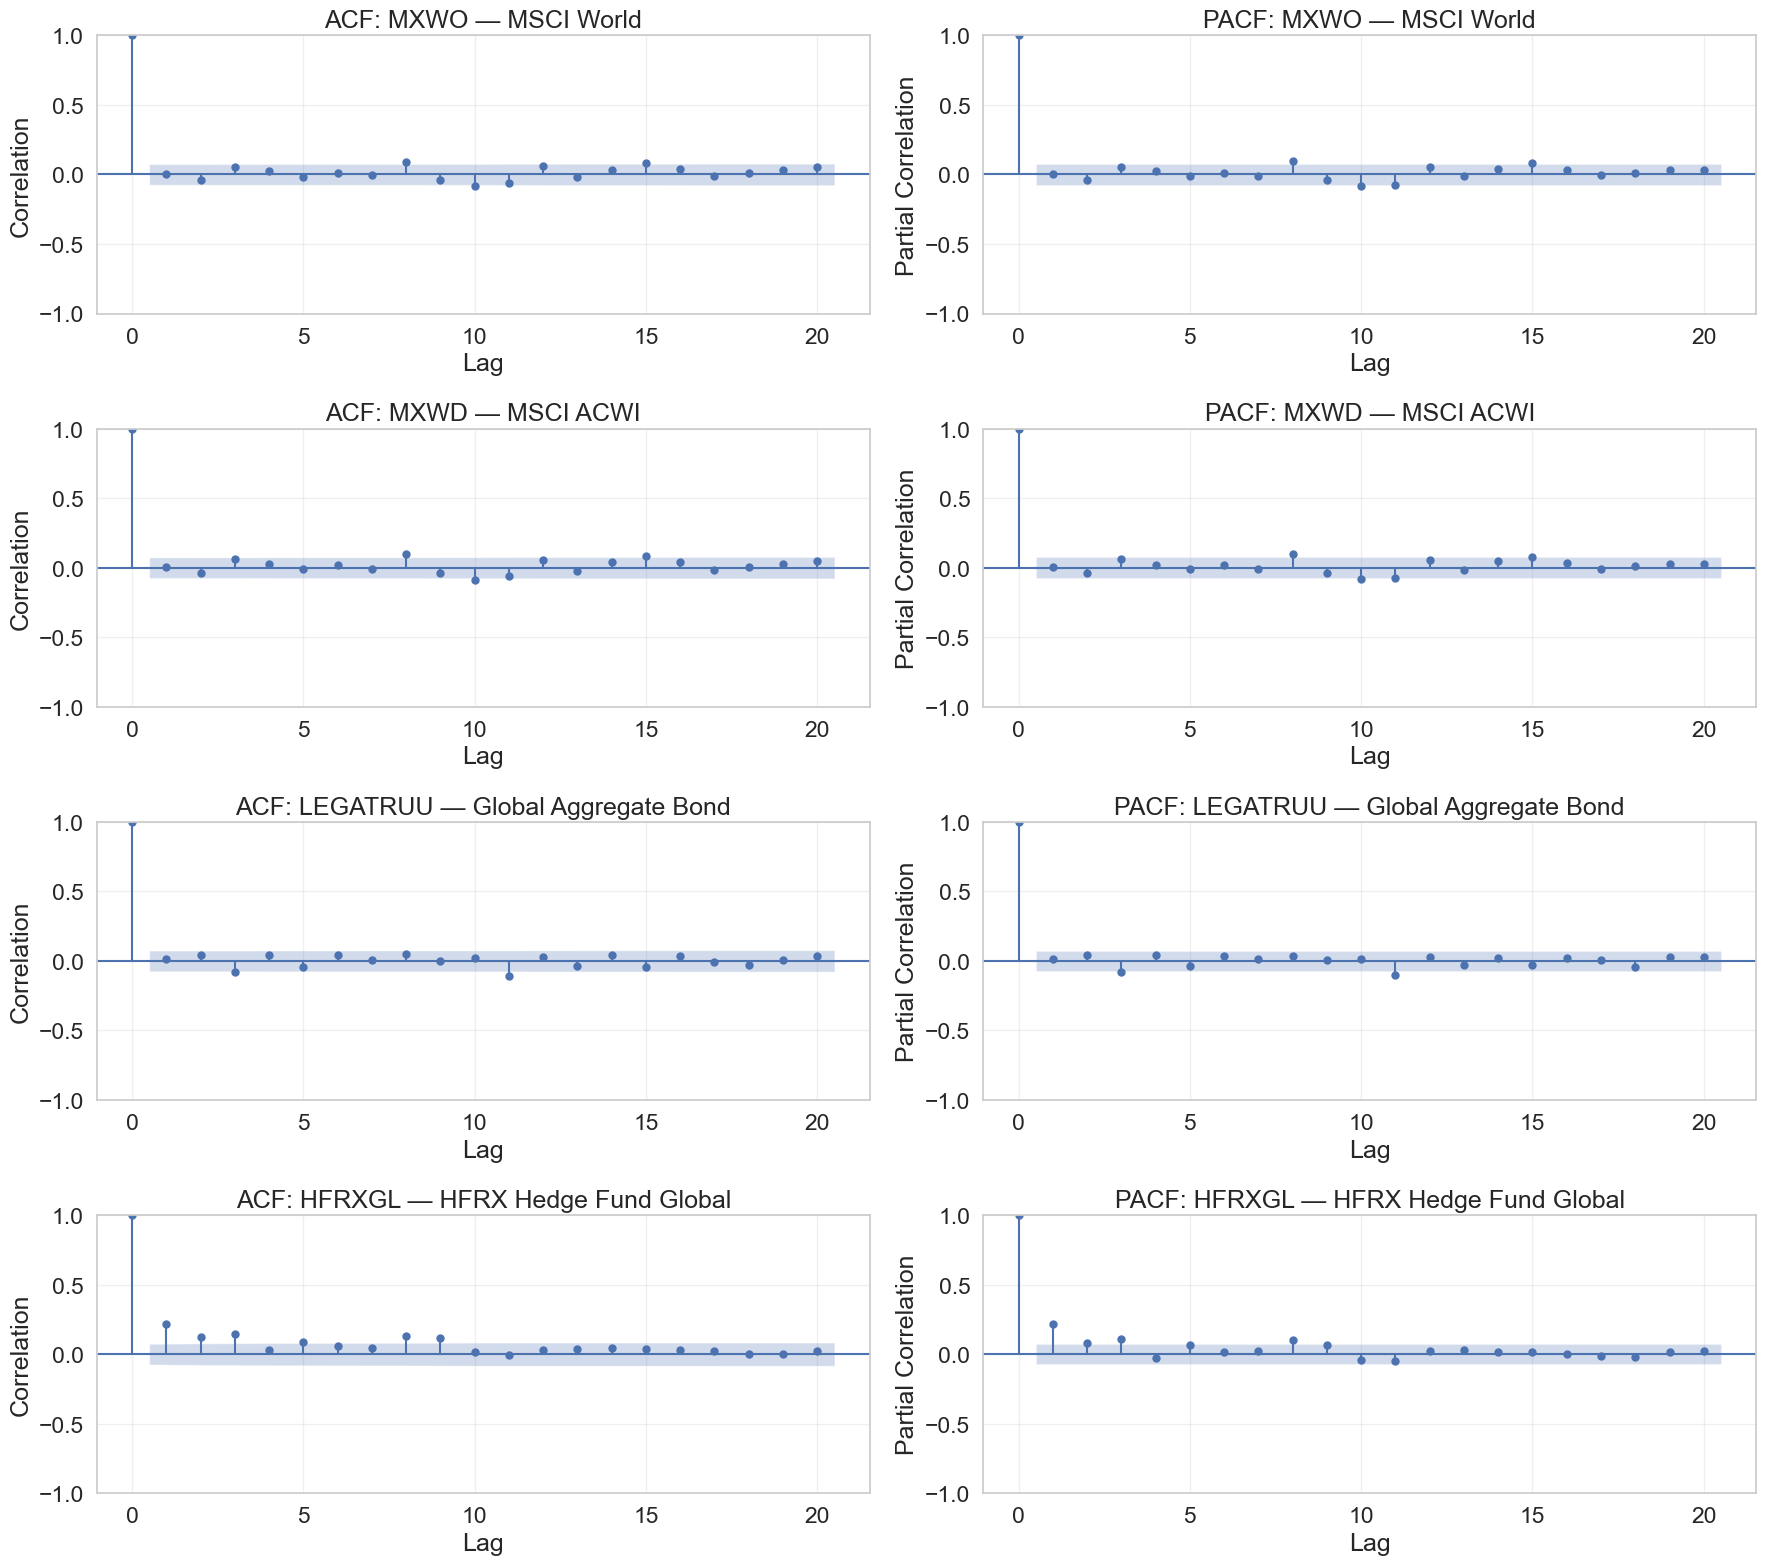

In [14]:
MAX_LAGS = 20

fig, axes = plt.subplots(len(TARGET_COLS), 2, figsize=(18, 4 * len(TARGET_COLS)))

for i, col in enumerate(TARGET_COLS):
    r = returns[col].dropna()
    plot_acf(r,  lags=MAX_LAGS, ax=axes[i, 0],
             title=f'ACF: {col} — {LABEL[col]}',  alpha=0.05)
    plot_pacf(r, lags=MAX_LAGS, ax=axes[i, 1],
             title=f'PACF: {col} — {LABEL[col]}', alpha=0.05)
    axes[i, 0].set_xlabel('Lag'); axes[i, 0].set_ylabel('Correlation')
    axes[i, 1].set_xlabel('Lag'); axes[i, 1].set_ylabel('Partial Correlation')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Ljung-Box Test for Autocorrelation

**H₀**: No autocorrelation up to lag k. A significant p-value (< 0.05) rejects H₀.

In [15]:
print("Ljung-Box test (H₀: no autocorrelation up to lag k)")
print("=" * 60)

for col in TARGET_COLS:
    lb = acorr_ljungbox(returns[col].dropna(), lags=[5, 10, 15, 20])
    print(f"\n{col} — {LABEL[col]}:")
    for lag_val, (_, row) in zip([5, 10, 15, 20], lb.iterrows()):
        stars = '***' if row['lb_pvalue'] < 0.001 else \
                '** ' if row['lb_pvalue'] < 0.01 else \
                '*  ' if row['lb_pvalue'] < 0.05 else '   '
        print(f"  Lag {lag_val:2d}: Q = {row['lb_stat']:8.4f},  p = {row['lb_pvalue']:.4f}  {stars}")

print("\nSignificance: *** p<0.001  ** p<0.01  * p<0.05")

Ljung-Box test (H₀: no autocorrelation up to lag k)

MXWO — MSCI World:
  Lag  5: Q =   3.7194,  p = 0.5905     
  Lag 10: Q =  16.3144,  p = 0.0910     
  Lag 15: Q =  27.3792,  p = 0.0258  *  
  Lag 20: Q =  31.2372,  p = 0.0521     

MXWD — MSCI ACWI:
  Lag  5: Q =   4.0704,  p = 0.5393     
  Lag 10: Q =  17.4323,  p = 0.0653     
  Lag 15: Q =  28.4624,  p = 0.0188  *  
  Lag 20: Q =  32.0118,  p = 0.0432  *  

LEGATRUU — Global Aggregate Bond:
  Lag  5: Q =   8.3823,  p = 0.1364     
  Lag 10: Q =  11.6799,  p = 0.3071     
  Lag 15: Q =  23.8265,  p = 0.0681     
  Lag 20: Q =  26.5486,  p = 0.1484     

HFRXGL — HFRX Hedge Fund Global:
  Lag  5: Q =  63.9540,  p = 0.0000  ***
  Lag 10: Q =  90.7371,  p = 0.0000  ***
  Lag 15: Q =  94.7913,  p = 0.0000  ***
  Lag 20: Q =  96.3138,  p = 0.0000  ***

Significance: *** p<0.001  ** p<0.01  * p<0.05


### 3.4 Volatility Clustering — ACF of Squared Returns

Significant autocorrelation in **squared returns** indicates **volatility clustering** (ARCH/GARCH effects): periods of high volatility tend to be followed by high volatility.

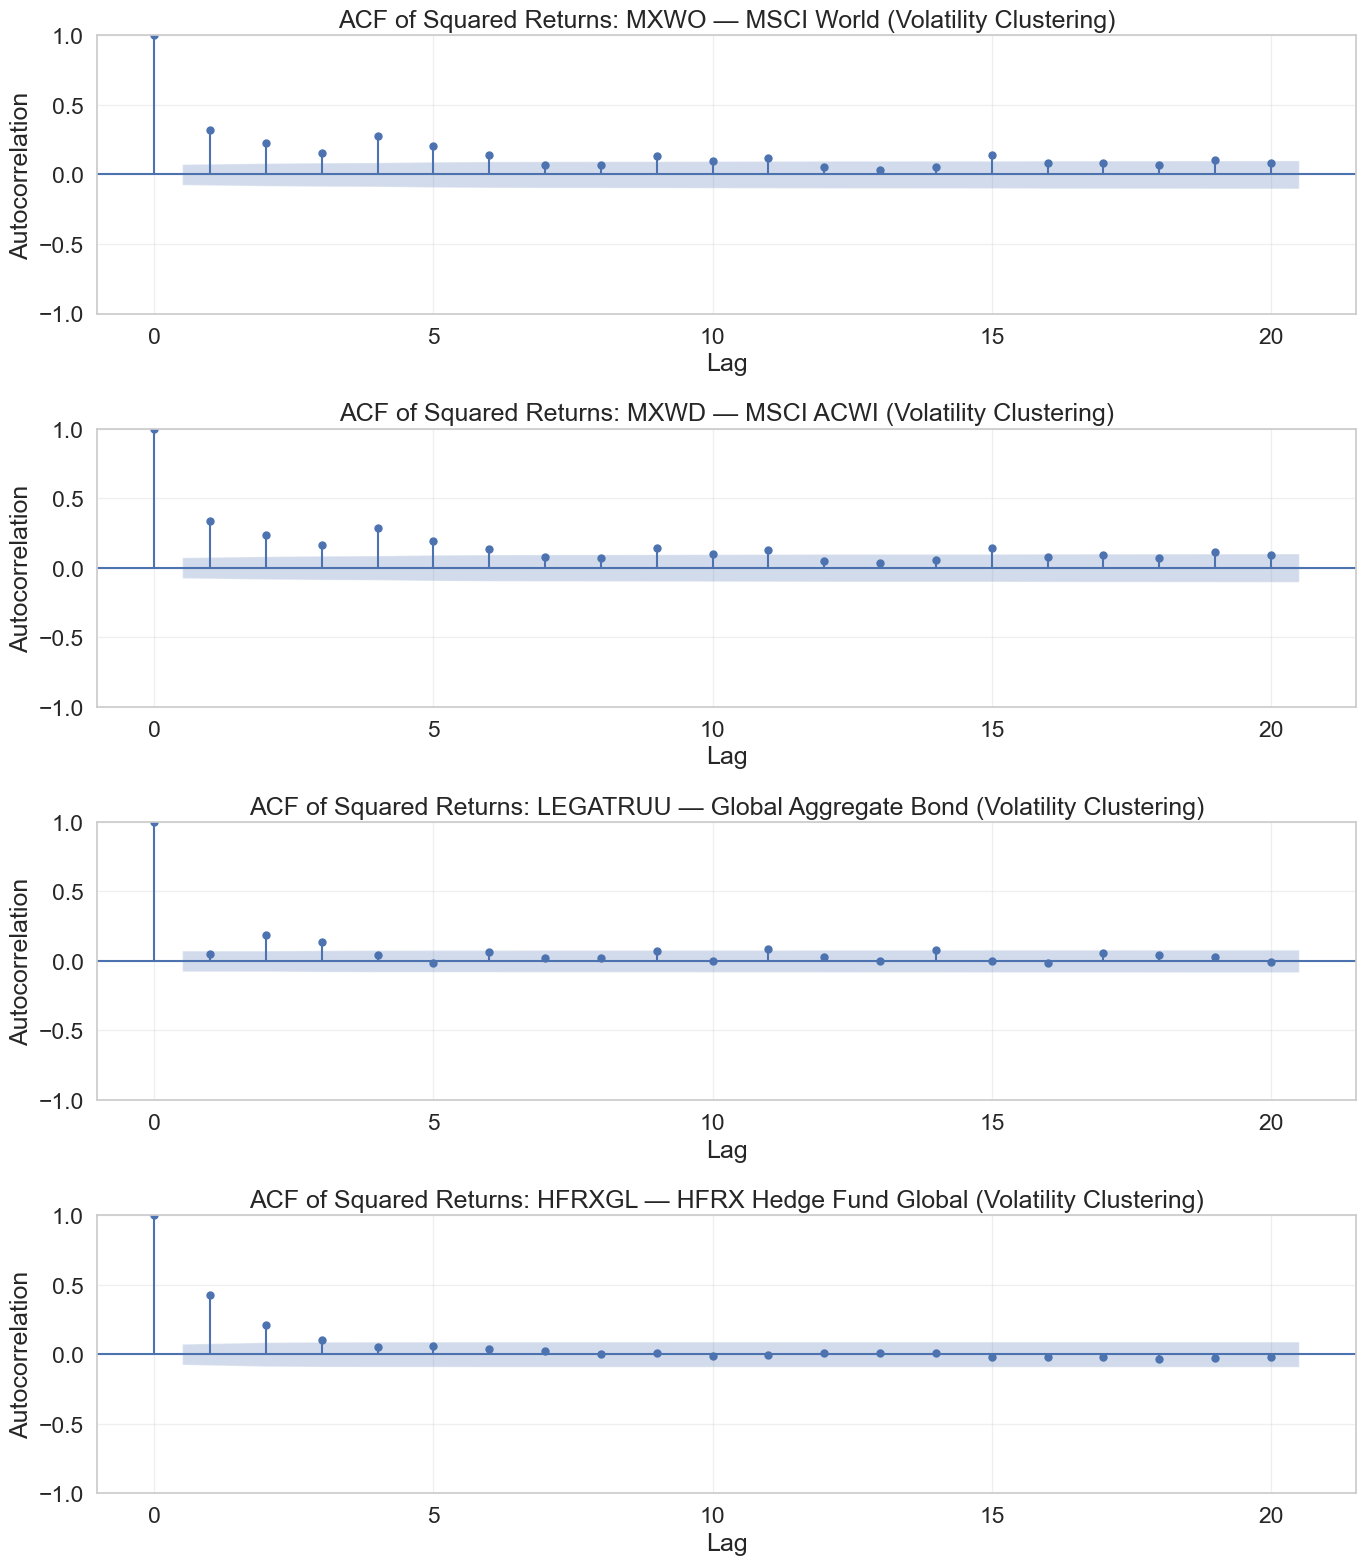

In [16]:
fig, axes = plt.subplots(len(TARGET_COLS), 1, figsize=(14, 4 * len(TARGET_COLS)))

for i, col in enumerate(TARGET_COLS):
    sq_ret = returns[col].dropna() ** 2
    plot_acf(sq_ret, lags=MAX_LAGS, ax=axes[i], alpha=0.05,
             title=f'ACF of Squared Returns: {col} — {LABEL[col]} (Volatility Clustering)')
    axes[i].set_xlabel('Lag')
    axes[i].set_ylabel('Autocorrelation')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.5 Formal Volatility Clustering Test — Engle's ARCH LM

**H₀**: No ARCH effects (constant variance / no clustering). A significant result confirms that the variance of returns is time-varying — a formal complement to the visual ACF of squared returns above.

In [17]:
print("Engle's ARCH LM test (H₀: no ARCH effects — no volatility clustering)")
print("=" * 70)

for col in TARGET_COLS:
    r = returns[col].dropna().values
    lm_stat, lm_pval, _, _ = het_arch(r, nlags=5)
    stars = '***' if lm_pval < 0.001 else \
            '** ' if lm_pval < 0.01  else \
            '*  ' if lm_pval < 0.05  else '   '
    conclusion = "ARCH effects present" if lm_pval < 0.05 else "No ARCH effects"
    print(f"{col:10s}: LM = {lm_stat:10.4f},  p = {lm_pval:.4f}  {stars}  → {conclusion}")

print("\nSignificance: *** p<0.001  ** p<0.01  * p<0.05")
print("\nA significant result confirms the volatility clustering visible in the ACF of squared")
print("returns above is statistically robust — not a visual artefact.")

Engle's ARCH LM test (H₀: no ARCH effects — no volatility clustering)
MXWO      : LM =   116.8561,  p = 0.0000  ***  → ARCH effects present
MXWD      : LM =   122.4508,  p = 0.0000  ***  → ARCH effects present
LEGATRUU  : LM =    39.0577,  p = 0.0000  ***  → ARCH effects present
HFRXGL    : LM =   127.5373,  p = 0.0000  ***  → ARCH effects present

Significance: *** p<0.001  ** p<0.01  * p<0.05

A significant result confirms the volatility clustering visible in the ACF of squared
returns above is statistically robust — not a visual artefact.


---
## 4. Monster Index Construction

The **Monster Index** is our replication target: a non-investable, multi-asset black-box combining:
- **50% HFRXGL** — Hedge Fund Research HFRX Global Index
- **25% MXWO** — MSCI World (global developed equities)
- **25% LEGATRUU** — Bloomberg Global Aggregate Bond Index

We will attempt to replicate this with a **long/short portfolio of liquid futures contracts**.

In [18]:
# ── Monster Index weights ──────────────────────────────────────────────────────
MONSTER_WEIGHTS = {'HFRXGL': 0.50, 'MXWO': 0.25, 'LEGATRUU': 0.25}

# Weighted sum of weekly returns
target_returns = sum(returns[col] * w for col, w in MONSTER_WEIGHTS.items())
target_returns.name = 'Monster_Index'

# Futures returns (replication instruments)
futures_returns = returns[FUTURES_COLS].copy()

# Alignment check
assert (target_returns.index == futures_returns.index).all(), \
    "Date misalignment between target_returns and futures_returns!"

print(f"Monster Index weights : {MONSTER_WEIGHTS}")
print(f"Sum of weights        : {sum(MONSTER_WEIGHTS.values())} ✓")
print(f"target_returns  shape : {target_returns.shape}")
print(f"futures_returns shape : {futures_returns.shape}")
print(f"Date range            : {target_returns.index[0].date()} → {target_returns.index[-1].date()}")

Monster Index weights : {'HFRXGL': 0.5, 'MXWO': 0.25, 'LEGATRUU': 0.25}
Sum of weights        : 1.0 ✓
target_returns  shape : (704,)
futures_returns shape : (704, 11)
Date range            : 2007-10-30 → 2021-04-20


---
## 5. Target Index Statistics

> **Note on data range**: this analysis uses the full 2007–2021 history, which includes the **2008 Global Financial Crisis**. Statistics (especially max drawdown and Sharpe ratio) will differ significantly from analyses using post-2011 data.

### 5.1 Performance Metrics

In [19]:
cum_monster = (1 + target_returns).cumprod()
dd_monster  = 1 - cum_monster / cum_monster.cummax()

metrics = pd.DataFrame({
    'Statistic': [
        'Annualized Return', 'Annualized Volatility', 'Sharpe Ratio',
        'Max Drawdown', 'Skewness', 'Kurtosis'
    ],
    'Value': [
        fmt_pct(target_returns.mean() * ANN),
        fmt_pct(target_returns.std() * np.sqrt(ANN)),
        f"{(target_returns.mean() * ANN) / (target_returns.std() * np.sqrt(ANN)):.2f}",
        fmt_pct(dd_monster.max()),
        f"{target_returns.skew():.2f}",
        f"{target_returns.kurtosis():.2f}",
    ]
})

print("Monster Index — Performance Statistics (weekly, 2007-2021):")
display(metrics)

Monster Index — Performance Statistics (weekly, 2007-2021):


,Statistic,Value
0,Annualized Return,2.57%
1,Annualized Volatility,6.33%
2,Sharpe Ratio,0.41
3,Max Drawdown,29.01%
4,Skewness,-1.35
5,Kurtosis,7.64


### 5.2 Deep Dive: Historical Worst Weeks

In [20]:
worst_weeks = (
    target_returns
    .sort_values()
    .head(5)
    .rename('Weekly Return')
    .to_frame()
)
worst_weeks.index.name = 'Date'
worst_weeks['Weekly Return'] = worst_weeks['Weekly Return'].map(lambda x: f"{x * 100:.2f}%")

print("5 worst weeks in the Monster Index history:")
display(worst_weeks)

5 worst weeks in the Monster Index history:


,Weekly Return
Date,
2020-03-17,-6.69%
2008-10-07,-4.90%
2008-10-14,-3.81%
2008-10-28,-3.41%
2011-08-09,-3.19%


### 5.3 Cumulative Return & Drawdown

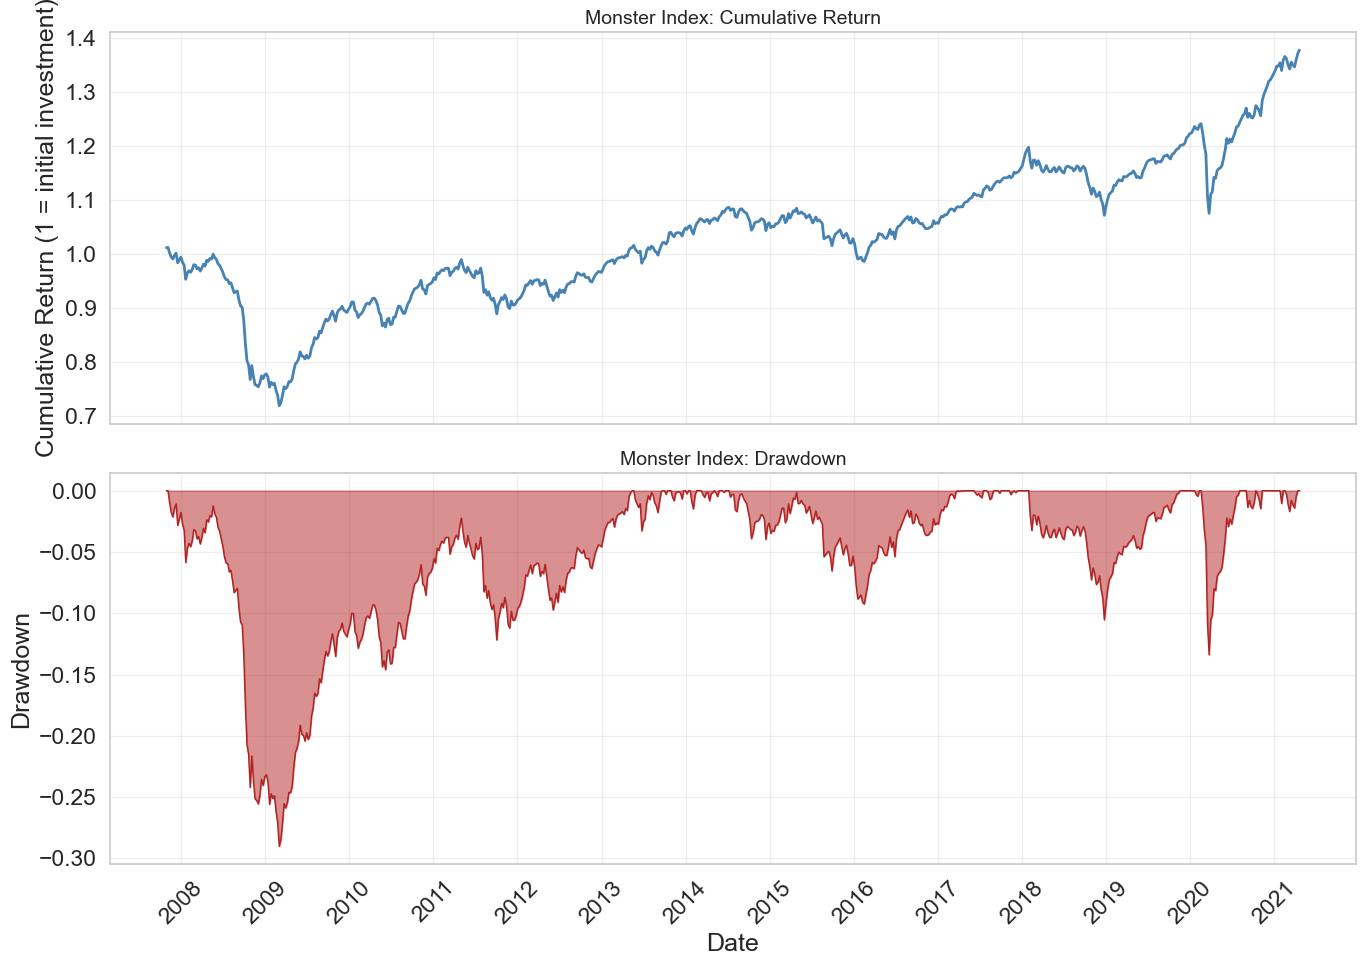

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Cumulative return
ax1.plot(cum_monster, color='steelblue', linewidth=2)
ax1.set_title('Monster Index: Cumulative Return', fontsize=14)
ax1.set_ylabel('Cumulative Return (1 = initial investment)')
ax1.grid(True, alpha=0.3)

# Drawdown
ax2.fill_between(dd_monster.index, -dd_monster, 0, color='firebrick', alpha=0.5)
ax2.plot(-dd_monster, color='firebrick', linewidth=1)
ax2.set_title('Monster Index: Drawdown', fontsize=14)
ax2.set_ylabel('Drawdown')
ax2.set_xlabel('Date')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.4 Risk-Return Profile (Target vs Universe)

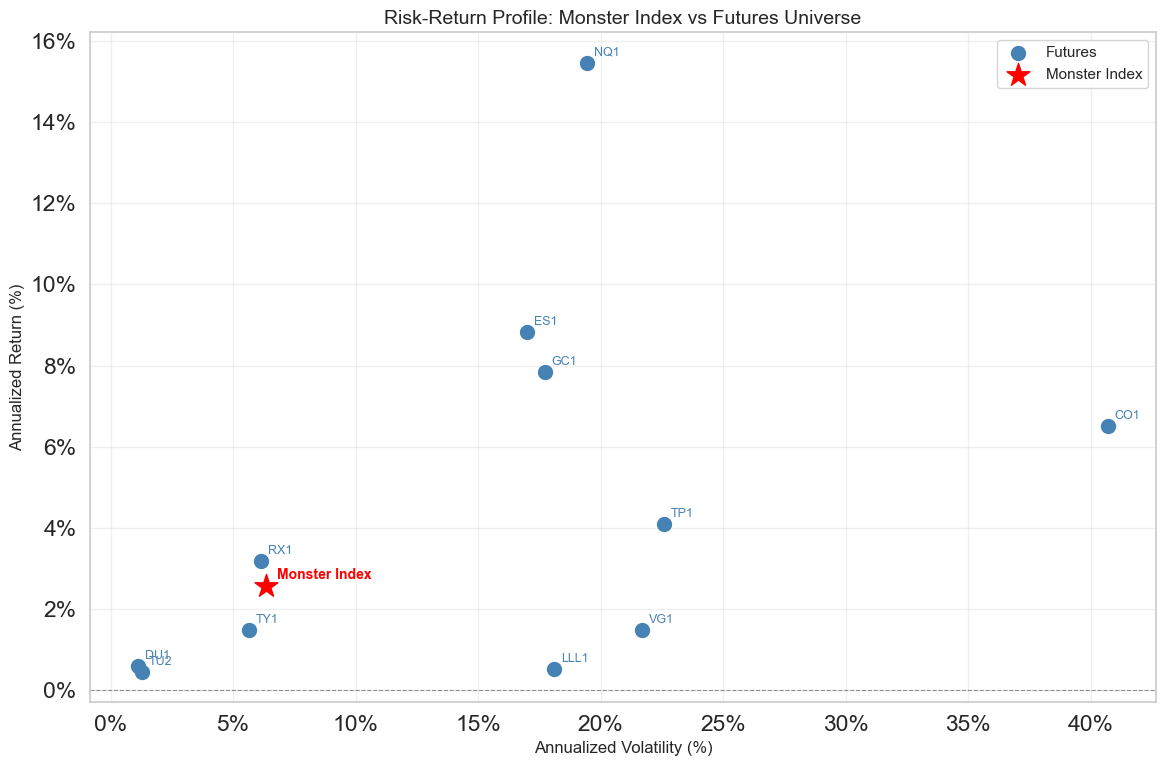

In [22]:
ann_ret = returns[FUTURES_COLS].mean() * ANN
ann_vol = returns[FUTURES_COLS].std() * np.sqrt(ANN)

monster_ret = target_returns.mean() * ANN
monster_vol = target_returns.std() * np.sqrt(ANN)

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(ann_vol * 100, ann_ret * 100,
           color='steelblue', s=100, zorder=3, label='Futures')
for col in FUTURES_COLS:
    ax.annotate(col,
                xy=(ann_vol[col] * 100, ann_ret[col] * 100),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, color='steelblue')

ax.scatter(monster_vol * 100, monster_ret * 100,
           color='red', s=300, marker='*', zorder=4, label='Monster Index')
ax.annotate('Monster Index',
            xy=(monster_vol * 100, monster_ret * 100),
            xytext=(8, 5), textcoords='offset points',
            fontsize=10, fontweight='bold', color='red')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_title('Risk-Return Profile: Monster Index vs Futures Universe', fontsize=14)
ax.set_xlabel('Annualized Volatility (%)', fontsize=12)
ax.set_ylabel('Annualized Return (%)', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 Rolling Correlation: Monster Index vs Futures

Futures contracts ranked by absolute correlation with Monster Index:


,Correlation,Abs Correlation,Instrument
ES1,0.8379,0.8379,S&P 500 Future
NQ1,0.7469,0.7469,Nasdaq 100 Future
VG1,0.7306,0.7306,EuroStoxx 50 Future
TP1,0.5988,0.5988,TOPIX Future
LLL1,0.4987,0.4987,MSCI EM Future
CO1,0.4448,0.4448,Brent Crude Future
GC1,0.2183,0.2183,Gold Future
TY1,-0.1191,0.1191,10Y US Treasury Future
RX1,-0.1307,0.1307,Bund Future (10Y GER)
TU2,-0.1528,0.1528,2Y US Treasury Future


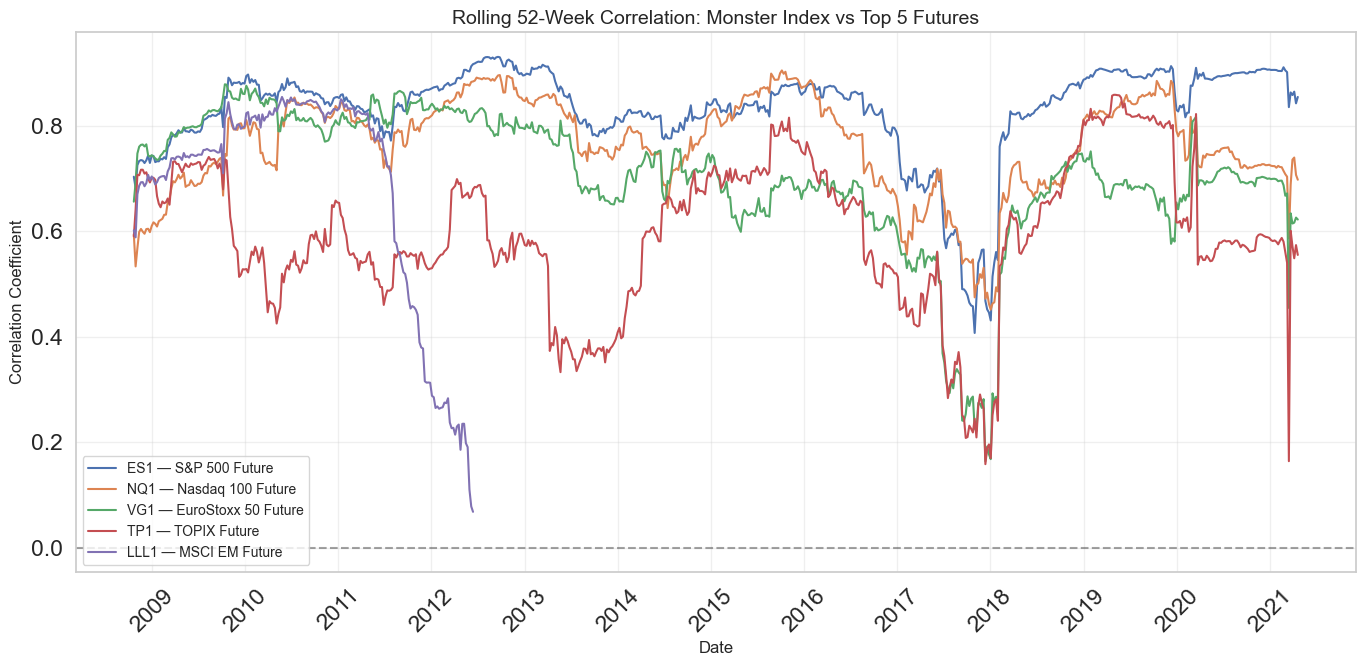

In [23]:
# Rank futures by absolute correlation with Monster Index
corr_rank = futures_returns.corrwith(target_returns).abs().sort_values(ascending=False)
top5_futures = corr_rank.index[:5].tolist()

print("Futures contracts ranked by absolute correlation with Monster Index:")
corr_full = futures_returns.corrwith(target_returns).sort_values(ascending=False)
corr_df = pd.DataFrame({'Correlation': corr_full, 'Abs Correlation': corr_full.abs()})
corr_df['Instrument'] = corr_df.index.map(LABEL)
display(corr_df.round(4))

# Rolling correlation plot
rolling_window = 52
fig, ax = plt.subplots(figsize=(14, 7))

for fut in top5_futures:
    rc = target_returns.rolling(rolling_window).corr(futures_returns[fut])
    ax.plot(rc, linewidth=1.5, label=f"{fut} — {LABEL[fut]}")

ax.axhline(0, color='k', linestyle='--', alpha=0.4)
ax.set_title(f'Rolling {rolling_window}-Week Correlation: Monster Index vs Top 5 Futures',
             fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.6 Scatter Matrix: Monster Index vs Top 5 Correlated Futures

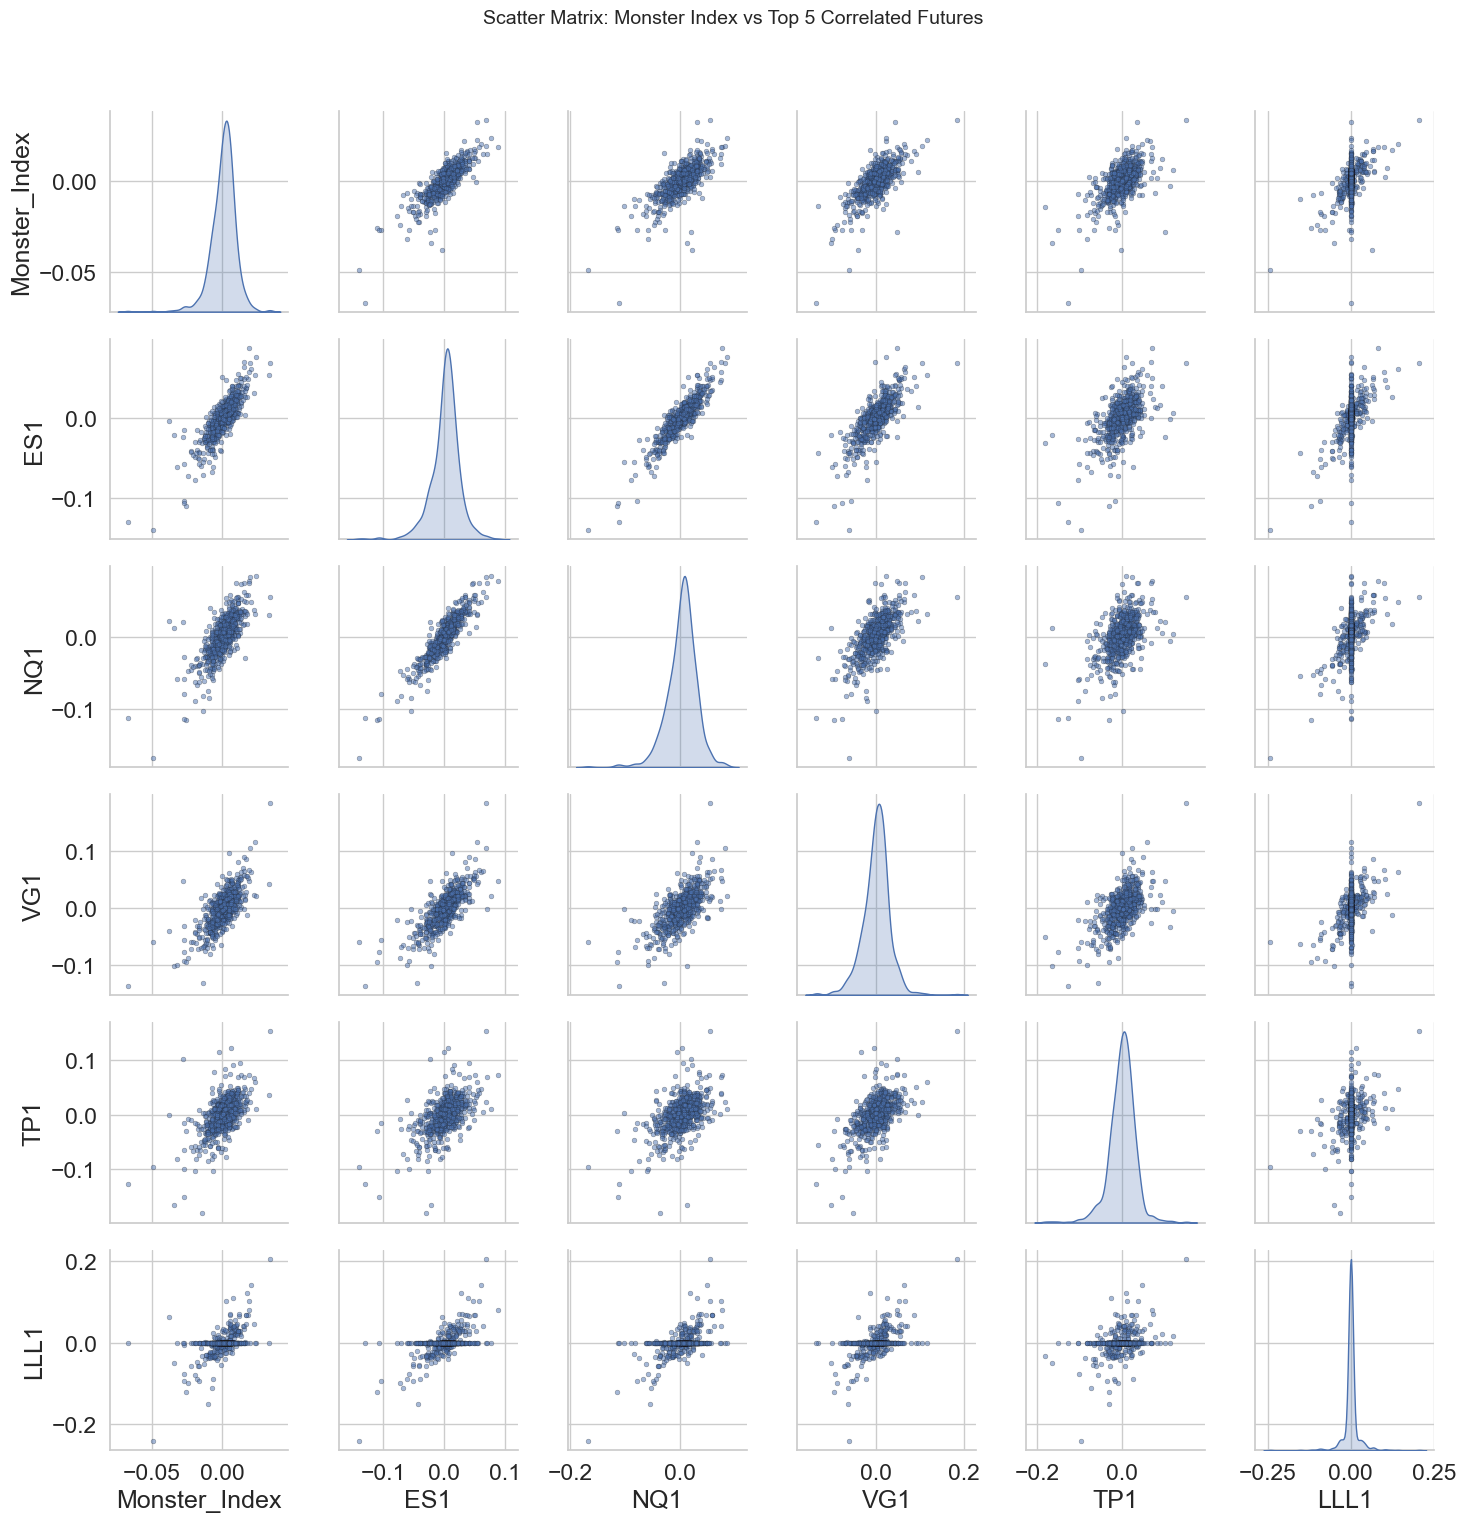

In [24]:
scatter_data = pd.concat(
    [target_returns.rename('Monster_Index'), futures_returns[top5_futures]],
    axis=1
)

g = sns.pairplot(
    scatter_data,
    kind='scatter',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 12, 'edgecolor': 'k', 'linewidth': 0.3}
)
g.fig.suptitle('Scatter Matrix: Monster Index vs Top 5 Correlated Futures',
               fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.7 Multicollinearity Check: Variance Inflation Factor (VIF)

In [25]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = returns[FUTURES_COLS].dropna()
X_const = sm.add_constant(X)

vif_data = pd.DataFrame({
    'Feature': X.columns,
    'VIF':     [variance_inflation_factor(X_const.values, i + 1)
                for i in range(X.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_data['Instrument'] = vif_data['Feature'].map(LABEL)
vif_data['VIF'] = vif_data['VIF'].round(2)

print("Variance Inflation Factor — Futures Returns:")
display(vif_data[['Feature', 'Instrument', 'VIF']])

print("\nRegola empirica:")
print("  VIF > 5  → possibile multicollinearità")
print("  VIF > 10 → forte multicollinearità tra i futures")

Variance Inflation Factor — Futures Returns:


,Feature,Instrument,VIF
0,ES1,S&P 500 Future,8.97
1,NQ1,Nasdaq 100 Future,6.16
2,VG1,EuroStoxx 50 Future,2.91
3,TY1,10Y US Treasury Future,2.75
4,RX1,Bund Future (10Y GER),2.40
5,TU2,2Y US Treasury Future,2.23
6,DU1,Schatz 2Y GER Future,2.07
7,TP1,TOPIX Future,1.70
8,LLL1,MSCI EM Future,1.57
9,CO1,Brent Crude Future,1.39



Regola empirica:
  VIF > 5  → possibile multicollinearità
  VIF > 10 → forte multicollinearità tra i futures


### 5.8 Principal Component Analysis on Futures Returns

PCA reveals the underlying **factor structure** of the 11 futures contracts — how many independent risk dimensions they truly span. If a few PCs explain most of the variance, the replication problem is lower-dimensional than it appears, which motivates sparse regression approaches (Lasso / Elastic Net).

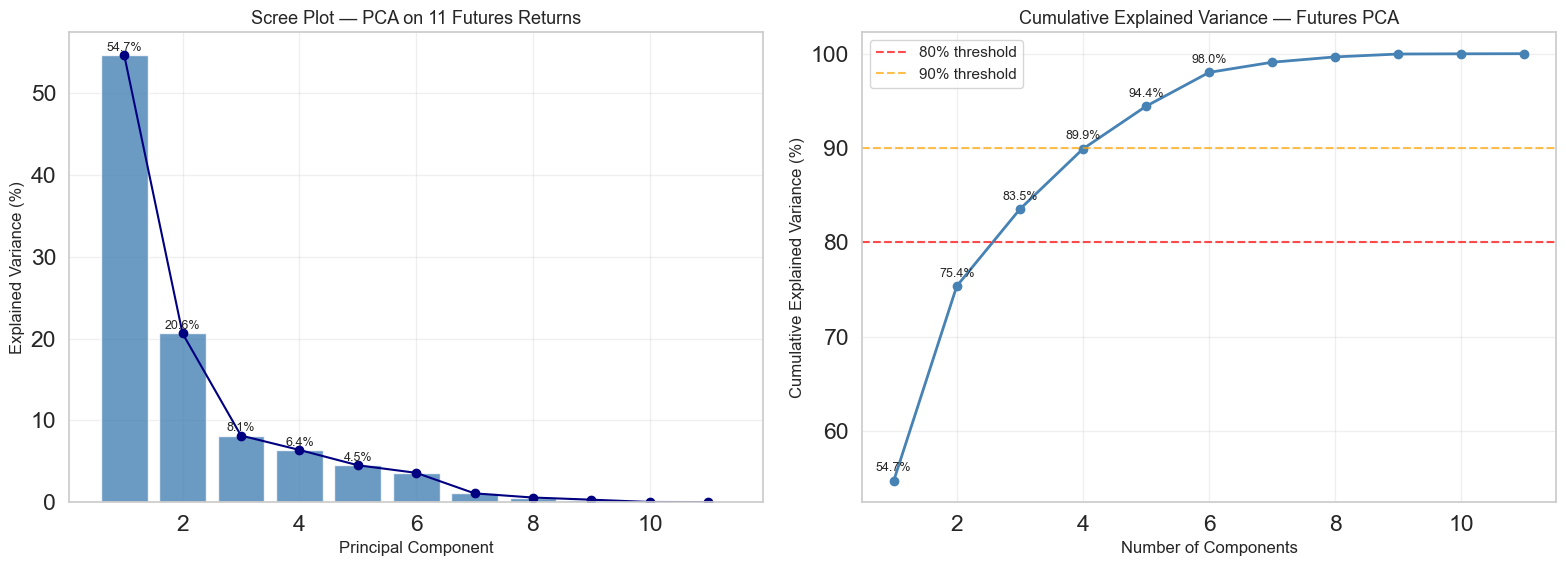

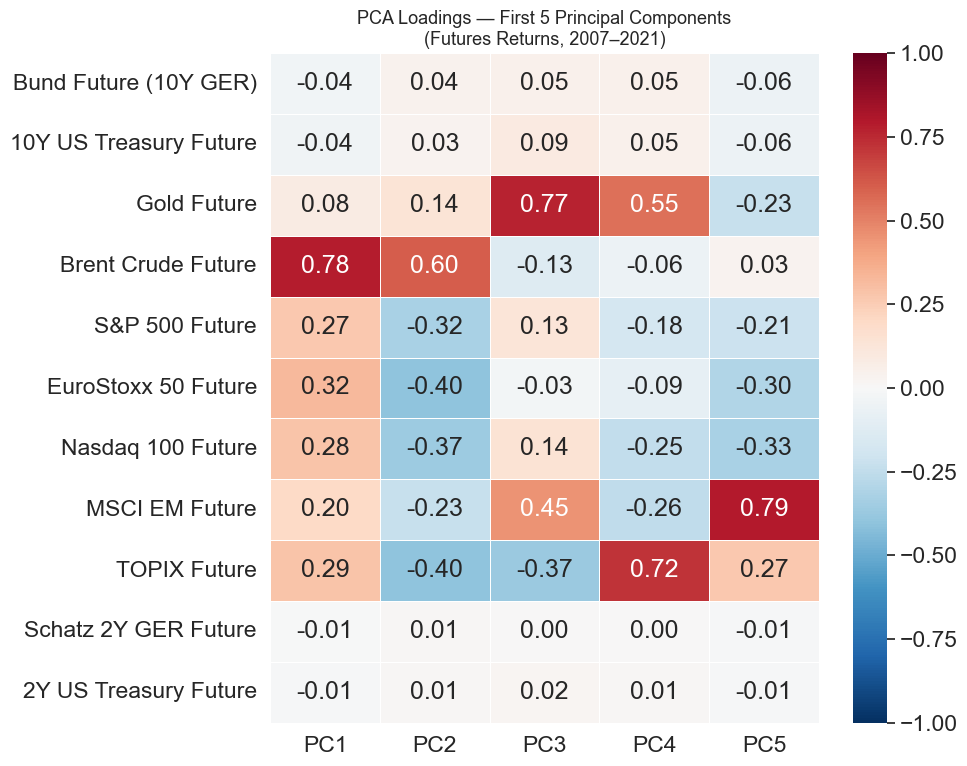

PCs needed to explain ≥ 80% of variance: 3
PCs needed to explain ≥ 90% of variance: 5
Variance explained by first 3 PCs      : 83.5%


In [26]:
pca = PCA()
pca.fit(futures_returns.dropna())

explained   = pca.explained_variance_ratio_
cumulative  = np.cumsum(explained)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
ax1.bar(range(1, len(explained) + 1), explained * 100, color='steelblue', alpha=0.8)
ax1.plot(range(1, len(explained) + 1), explained * 100, 'o-', color='navy', linewidth=1.5)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Explained Variance (%)', fontsize=12)
ax1.set_title('Scree Plot — PCA on 11 Futures Returns', fontsize=13)
ax1.grid(True, alpha=0.3)
for i, v in enumerate(explained[:5]):
    ax1.text(i + 1, v * 100 + 0.5, f'{v*100:.1f}%', ha='center', fontsize=9)

# Cumulative variance
ax2.plot(range(1, len(cumulative) + 1), cumulative * 100, 'o-', color='steelblue', linewidth=2)
ax2.axhline(80, color='red',    linestyle='--', alpha=0.7, label='80% threshold')
ax2.axhline(90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
ax2.set_title('Cumulative Explained Variance — Futures PCA', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
for i, v in enumerate(cumulative[:6]):
    ax2.text(i + 1, v * 100 + 1, f'{v*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# PC loadings heatmap (first 5 PCs)
loadings = pd.DataFrame(
    pca.components_[:5].T,
    index=[LABEL[c] for c in FUTURES_COLS],
    columns=[f'PC{i+1}' for i in range(5)]
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('PCA Loadings — First 5 Principal Components\n(Futures Returns, 2007–2021)', fontsize=13)
plt.tight_layout()
plt.show()

n_80 = np.searchsorted(cumulative, 0.80) + 1
n_90 = np.searchsorted(cumulative, 0.90) + 1
print(f"PCs needed to explain ≥ 80% of variance: {n_80}")
print(f"PCs needed to explain ≥ 90% of variance: {n_90}")
print(f"Variance explained by first 3 PCs      : {cumulative[2]*100:.1f}%")

---
## 6. Deliverable

The following two objects are the output of this notebook, to be used by teammates for the replication model.

| Object | Type | Shape | Description |
|---|---|---|---|
| `target_returns` | `pd.Series` | (704,) | Weekly Monster Index returns, DatetimeIndex |
| `futures_returns` | `pd.DataFrame` | (704, 11) | Weekly returns of 11 futures contracts |

In [27]:
print("=" * 55)
print("DELIVERABLE SUMMARY")
print("=" * 55)
print(f"target_returns")
print(f"  Type   : {type(target_returns).__name__}")
print(f"  Shape  : {target_returns.shape}")
print(f"  Name   : '{target_returns.name}'")
print(f"  Range  : {target_returns.index[0].date()} → {target_returns.index[-1].date()}")
print()
print(f"futures_returns")
print(f"  Type   : {type(futures_returns).__name__}")
print(f"  Shape  : {futures_returns.shape}")
print(f"  Cols   : {futures_returns.columns.tolist()}")
print(f"  Range  : {futures_returns.index[0].date()} → {futures_returns.index[-1].date()}")
print()
print(f"Indices aligned : {(target_returns.index == futures_returns.index).all()} ✓")
print("=" * 55)

# ── Optional: persist to disk for teammates ───────────────────────────────────
# target_returns.to_csv('target_returns.csv')
# futures_returns.to_csv('futures_returns.csv')
# OR use pickle for exact dtype preservation:
# import pickle
# with open('lab3_deliverables.pkl', 'wb') as f:
#     pickle.dump({'target_returns': target_returns,
#                  'futures_returns': futures_returns}, f)

DELIVERABLE SUMMARY
target_returns
  Type   : Series
  Shape  : (704,)
  Name   : 'Monster_Index'
  Range  : 2007-10-30 → 2021-04-20

futures_returns
  Type   : DataFrame
  Shape  : (704, 11)
  Cols   : ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1', 'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']
  Range  : 2007-10-30 → 2021-04-20

Indices aligned : True ✓
